# Womersley Flow in a Hemi-Equilateral Triangular Duct

**Authors:** Erico Lopes de Souza  and Andre Von Borries Lopes  
**Institution:** Université Paris Saclay / Universidade de Brasília (UnB)

---

This notebook solves the **Womersley flow** (oscillatory pressure-driven viscous flow) in a **30-60-90 hemi-equilateral triangular duct** using the Finite Element Method (FEM) via [FEniCSx](https://fenicsproject.org). Results are validated against the closed-form analytical series solution.

### Installation
```bash
conda install -c conda-forge fenics-dolfinx mpich gmsh python-gmsh
pip install Pillow
```

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpi4py import MPI

import gmsh
from dolfinx.io import gmsh as gmshio
from dolfinx import fem, mesh as dmesh
from dolfinx.fem.petsc import LinearProblem
from dolfinx.fem import (functionspace, Function, Constant,
                          form, assemble_scalar, locate_dofs_topological,
                          dirichletbc)
import ufl
from ufl import dx, grad, inner, TrialFunction, TestFunction, split
from basix.ufl import element as basix_element, mixed_element

## 1. Domain Geometry

The cross-section is the **hemi-equilateral (30-60-90) triangle**:

$$\Gamma = \left\{(x,y) \in \mathbb{R}^2 : 0 < x < 1,\quad 0 < y < \frac{x}{\sqrt{3}}\right\}$$

with vertices and interior angles:

| Vertex | Coordinates | Angle |
|--------|-------------|-------|
| $A$ | $(0,\,0)$ | $30°$ |
| $B$ | $(1,\,0)$ | $90°$ |
| $C$ | $(1,\,1/\sqrt{3})$ | $60°$ |

The mesh is generated with **gmsh** and imported via `gmshio.model_to_mesh`. FEniCSx requires **physical groups** to be declared before import — without them `gmshio` finds no cells and throws an `IndexError`.

In [ ]:
gmsh.initialize()
gmsh.option.setNumber("General.Verbosity", 0)
gmsh.model.add("hemi_equilateral")
h = 0.015   # characteristic mesh size (finer for smoother plots)

pts = [
    gmsh.model.geo.addPoint(0.0, 0.0,            0.0, h),
    gmsh.model.geo.addPoint(1.0, 0.0,            0.0, h),
    gmsh.model.geo.addPoint(1.0, 1.0/np.sqrt(3), 0.0, h),
]
lines = [
    gmsh.model.geo.addLine(pts[0], pts[1]),
    gmsh.model.geo.addLine(pts[1], pts[2]),
    gmsh.model.geo.addLine(pts[2], pts[0]),
]
surf = gmsh.model.geo.addPlaneSurface([gmsh.model.geo.addCurveLoop(lines)])
gmsh.model.geo.synchronize()

# Physical groups are mandatory for dolfinx gmshio
gmsh.model.addPhysicalGroup(2, [surf], tag=1)   # surface domain
gmsh.model.addPhysicalGroup(1, lines,  tag=2)   # boundary lines

gmsh.model.mesh.generate(2)

domain, *_ = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0, gdim=2)
gmsh.finalize()
print(f"Mesh created: {domain.topology.index_map(2).size_local} triangles")

## 2. Function Spaces and Boundary Conditions

The solution requires finding two scalar fields simultaneously: $w_c(x,y)$ and $w_s(x,y)$. We use a **mixed function space**:

$$W = V \times V, \qquad V = H^1_0(\Gamma) = \{v \in H^1(\Gamma) : v|_{\partial\Gamma} = 0\}$$

Each component is discretized with **P2 Lagrange elements** (continuous piecewise quadratic polynomials). P2 is preferred over P1 because it achieves second-order convergence in the $H^1$ norm and captures the curved velocity profiles more accurately for the same mesh size.

The **no-slip condition** $w_c = w_s = 0$ on $\partial\Gamma$ is enforced as a homogeneous Dirichlet condition on all boundary facets.

> **Note on collapse:** `W.sub(i).collapse()` creates an independent copy of the subspace with its own DOF numbering. This is needed to define Dirichlet values (a `Function` in the collapsed space) while applying them to the mixed space.

In [39]:
P2 = basix_element("Lagrange", domain.basix_cell(), 2)
W  = functionspace(domain, mixed_element([P2, P2]))

W0, _ = W.sub(0).collapse()   # collapsed space for wc
W1, _ = W.sub(1).collapse()   # collapsed space for ws

# Locate all boundary facets
domain.topology.create_connectivity(domain.topology.dim - 1, domain.topology.dim)
boundary_facets = dmesh.locate_entities_boundary(
    domain, domain.topology.dim - 1,
    lambda x: np.ones(x.shape[1], dtype=bool)
)

dofs_0 = locate_dofs_topological((W.sub(0), W0), domain.topology.dim - 1, boundary_facets)
dofs_1 = locate_dofs_topological((W.sub(1), W1), domain.topology.dim - 1, boundary_facets)

bc0 = dirichletbc(Function(W0), dofs_0, W.sub(0))   # zero by default
bc1 = dirichletbc(Function(W1), dofs_1, W.sub(1))
bcs = [bc0, bc1]

# Sanity check: numerical area vs analytical A = sqrt(3)/6
A_area = assemble_scalar(form(Constant(domain, np.float64(1.0)) * dx))
print(f"Mesh area:  {A_area:.6f}   (analytical sqrt(3)/6 = {np.sqrt(3)/6:.6f})")

Mesh area:  0.288675   (analytical sqrt(3)/6 = 0.288675)


## 3. Governing Equations and Weak Formulation

### 3.1 Strong Form

The normalized unsteady Navier-Stokes equation for axial velocity $w(x,y,t)$ is:

$$\frac{\partial w}{\partial t} = \cos(\alpha^2 t) + \nabla^2 w$$

where $\alpha = L\sqrt{\omega/\nu}$ is the **Womersley number** measuring the ratio of oscillatory inertia to viscous forces. We seek a time-periodic solution of the form:

$$w(x,y,t) = w_c(x,y)\,\cos(\alpha^2 t) + w_s(x,y)\,\sin(\alpha^2 t)$$

Substituting and separating cosine and sine contributions yields the **coupled elliptic system**:

$$\nabla^2 w_c - \alpha^2 w_s = -1 \qquad \text{in } \Gamma \tag{1}$$
$$\nabla^2 w_s + \alpha^2 w_c = 0 \qquad\quad \text{in } \Gamma \tag{2}$$
$$w_c = w_s = 0 \qquad\qquad\quad \text{on } \partial\Gamma \tag{3}$$

### 3.2 Weak Form Derivation

**Equation (1):** multiply by test function $v_c \in H^1_0(\Gamma)$ and integrate over $\Gamma$:

$$\int_\Gamma (\nabla^2 w_c)\,v_c\,dA - \alpha^2 \int_\Gamma w_s\,v_c\,dA = -\int_\Gamma v_c\,dA$$

Apply **Green's first identity**: $\int_\Gamma (\nabla^2 u)v\,dA = -\int_\Gamma \nabla u \cdot \nabla v\,dA + \oint_{\partial\Gamma} v\,(\nabla u \cdot \mathbf{n})\,ds$.

Since $v_c = 0$ on $\partial\Gamma$, the boundary term vanishes:

$$\boxed{\int_\Gamma \nabla w_c \cdot \nabla v_c\,dA + \alpha^2 \int_\Gamma w_s\,v_c\,dA = \int_\Gamma v_c\,dA} \tag{1'}$$

**Equation (2):** multiply by $v_s \in H^1_0(\Gamma)$ and apply the same identity:

$$\boxed{\int_\Gamma \nabla w_s \cdot \nabla v_s\,dA - \alpha^2 \int_\Gamma w_c\,v_s\,dA = 0} \tag{2'}$$

### 3.3 Combined Variational Problem

Find $(w_c, w_s) \in W$ such that $\forall\,(v_c, v_s) \in W$:

$$a\big((w_c,w_s),\,(v_c,v_s)\big) = \ell(v_c,v_s)$$

with bilinear and linear forms:

$$a = \int_\Gamma \nabla w_c \cdot \nabla v_c\,dA + \alpha^2\!\int_\Gamma w_s\,v_c\,dA + \int_\Gamma \nabla w_s \cdot \nabla v_s\,dA - \alpha^2\!\int_\Gamma w_c\,v_s\,dA$$

$$\ell = \int_\Gamma v_c\,dA$$

After FEM discretization, the system has an **anti-symmetric block structure**:

$$\begin{bmatrix} K & \alpha^2 M \\\ -\alpha^2 M & K \end{bmatrix} \begin{bmatrix} \mathbf{w}_c \\\ \mathbf{w}_s \end{bmatrix} = \begin{bmatrix} \mathbf{f} \\\ \mathbf{0} \end{bmatrix}$$

where $K$ is the **stiffness matrix** and $M$ is the **mass matrix**. This system is well-posed for all $\alpha \geq 0$ and is solved with a direct LU factorization (`pc_type: lu`).

### 3.4 Post-processing

From $w_c$ and $w_s$, the velocity **amplitude** and **phase angle** at each point are:

$$w_a(x,y) = \sqrt{w_c^2 + w_s^2}, \qquad \theta(x,y) = -\arctan\!\left(\frac{w_s}{w_c}\right)$$

The **cross-sectional mean** values used for validation (eqs. 28-29 in the paper) are:

$$\bar{w}_a = \sqrt{\bar{w}_c^2 + \bar{w}_s^2}, \qquad \bar{\theta} = -\arctan\!\left(\frac{\bar{w}_s}{\bar{w}_c}\right), \qquad \bar{w}_c = \frac{1}{A}\int_\Gamma w_c\,dA$$

In [40]:
def solve_womersley(alpha):
    uc, us = split(TrialFunction(W))
    vc, vs = split(TestFunction(W))
    a2 = np.float64(alpha**2)

    a = (inner(grad(uc), grad(vc)) + a2 * us * vc +
         inner(grad(us), grad(vs)) - a2 * uc * vs) * dx
    L = Constant(domain, np.float64(1.0)) * vc * dx

    prob = LinearProblem(a, L, bcs=bcs,
                         petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
                         petsc_options_prefix="womersley_")
    wh = prob.solve()
    wh.x.scatter_forward()          # sync PETSc vector → local array

    wc_h = Function(W0)
    wc_h.interpolate(wh.sub(0))
    wc_h.x.scatter_forward()

    ws_h = Function(W1)
    ws_h.interpolate(wh.sub(1))
    ws_h.x.scatter_forward()
    return wc_h, ws_h

def mean_val(f):
    """Cross-sectional mean: (1/A) * integral of f over Gamma."""
    return assemble_scalar(form(f * dx)) / A_area

## 4. Analytical Reference Solution

The paper derives an exact series solution by expanding $w_c$ and $w_s$ onto the Dirichlet eigenfunctions $\phi_{mn}$ of the Laplacian on $\Gamma$. The eigenvalues are:

$$\lambda_{mn} = \frac{4\pi^2}{3}\left(3m^2 + 3mn + n^2\right), \qquad m,n \geq 1$$

The series coefficients of the mean velocity (eq. 27 in the paper) are:

$$\bar{w}_c = \frac{1}{A}\sum_{m,n \geq 1} \frac{\lambda_{mn}}{\lambda_{mn}^2 + \alpha^4} \cdot \frac{\left(\int_\Gamma \phi_{mn}\,dA\right)^2}{\int_\Gamma \phi_{mn}^2\,dA}$$

$$\bar{w}_s = \frac{1}{A}\sum_{m,n \geq 1} \frac{\alpha^2}{\lambda_{mn}^2 + \alpha^4} \cdot \frac{\left(\int_\Gamma \phi_{mn}\,dA\right)^2}{\int_\Gamma \phi_{mn}^2\,dA}$$

Both integrals are available in closed form (eqs. 18-19). The **parity filter** removes modes where $\int_\Gamma \phi_{mn}\,dA = 0$ (both $m$ and $n$ even), which do not couple to the uniform pressure forcing.

In [41]:
def analytical_wbar(alpha, N=40):
    """Compute mean velocity components (wc_bar, ws_bar) from the analytical series."""
    A_an = np.sqrt(3) / 6
    I2   = np.sqrt(3) / 8   # closed-form value of int(phi_mn^2 dA), eq. 19
    wc = ws = 0.0
    for m in range(1, N + 1):
        for n in range(1, N + 1):
            lmn = 4*np.pi**2/3 * (3*m**2 + 3*m*n + n**2)          # eigenvalue, eq. 16
            t1  = (1 - (-1)**m)     / (m       * (3*m + 2*n))      # eq. 18
            t2  = (1 - (-1)**n)     / (n       * (2*m +   n))
            t3  = (1 - (-1)**(m+n)) / ((m + n) * (3*m +   n))
            Imn = np.sqrt(3) / np.pi**2 * (t1 + t2 - t3)           # int(phi_mn dA)
            if Imn == 0.0:   # parity filter: both m,n even -> skip
                continue
            fac = Imn**2 / I2
            den = lmn**2 + alpha**4
            wc += lmn      / den * fac
            ws += alpha**2 / den * fac
    return wc / A_an, ws / A_an

## 5. Validation Sweep: $\alpha \in [0,\,100]$

We evaluate both methods for 50 values of $\alpha$. Two limiting behaviors provide physical intuition:

- **$\alpha \to 0$ (steady limit):** the problem reduces to Poiseuille flow. $\bar{w}_a$ is at its maximum and $\bar{\theta} = 0$ (velocity and pressure gradient are in phase).
- **$\alpha \to \infty$ (inertia-dominated limit):** the fluid cannot follow the fast oscillation. $\bar{w}_a \to 0$ and $\bar{\theta} \to -\pi/2$ (velocity lags pressure gradient by 90°).

In [42]:
alphas = np.linspace(0.0, 100.0, 50)
wa_fem = np.empty(len(alphas))
th_fem = np.empty(len(alphas))
wa_ana = np.empty(len(alphas))
th_ana = np.empty(len(alphas))

print("Running sweep (FEM + analytical)...")
for i, alpha in enumerate(alphas):
    wc_h, ws_h = solve_womersley(alpha)
    wc_m, ws_m = mean_val(wc_h), mean_val(ws_h)
    wa_fem[i]  = np.hypot(wc_m, ws_m)
    th_fem[i]  = -np.arctan2(ws_m, wc_m)

    wc_a, ws_a = analytical_wbar(alpha)
    wa_ana[i]  = np.hypot(wc_a, ws_a)
    th_ana[i]  = -np.arctan2(ws_a, wc_a)

    print(f"  alpha={alpha:6.1f}  w_a: FEM={wa_fem[i]:.5f}  Ana={wa_ana[i]:.5f}  "
          f"theta: FEM={th_fem[i]:.4f}  Ana={th_ana[i]:.4f}")

Running sweep (FEM + analytical)...
  alpha=   0.0  w_a: FEM=0.00685  Ana=0.00685  theta: FEM=-0.0000  Ana=-0.0000
  alpha=   2.0  w_a: FEM=0.00685  Ana=0.00685  theta: FEM=-0.0416  Ana=-0.0416
  alpha=   4.1  w_a: FEM=0.00675  Ana=0.00675  theta: FEM=-0.1646  Ana=-0.1646
  alpha=   6.1  w_a: FEM=0.00637  Ana=0.00637  theta: FEM=-0.3546  Ana=-0.3546
  alpha=   8.2  w_a: FEM=0.00562  Ana=0.00562  theta: FEM=-0.5717  Ana=-0.5717
  alpha=  10.2  w_a: FEM=0.00466  Ana=0.00466  theta: FEM=-0.7670  Ana=-0.7670
  alpha=  12.2  w_a: FEM=0.00376  Ana=0.00376  theta: FEM=-0.9170  Ana=-0.9171
  alpha=  14.3  w_a: FEM=0.00304  Ana=0.00304  theta: FEM=-1.0253  Ana=-1.0254
  alpha=  16.3  w_a: FEM=0.00248  Ana=0.00248  theta: FEM=-1.1037  Ana=-1.1038
  alpha=  18.4  w_a: FEM=0.00205  Ana=0.00205  theta: FEM=-1.1622  Ana=-1.1623
  alpha=  20.4  w_a: FEM=0.00173  Ana=0.00173  theta: FEM=-1.2075  Ana=-1.2076
  alpha=  22.4  w_a: FEM=0.00147  Ana=0.00147  theta: FEM=-1.2436  Ana=-1.2437
  alpha=  24.5  

## 6. Velocity Field Visualization

For a chosen $\alpha$, we visualize $w_a(x,y)$ and $\theta(x,y)$ over the cross-section. Since the FEM solution lives in a P2 space (DOFs at vertices and edge midpoints), it is first **interpolated to P1** (DOFs at vertices only) so each DOF coordinate maps directly to a mesh vertex — enabling clean `tripcolor` plots via `matplotlib.tri`.

In [ ]:
alpha_show = 5.0
wc_f, ws_f = solve_womersley(alpha_show)

# Interpolate to P1 for visualization
P1 = basix_element("Lagrange", domain.basix_cell(), 1)
V1 = functionspace(domain, P1)

wc_p1 = Function(V1);  wc_p1.interpolate(wc_f)
ws_p1 = Function(V1);  ws_p1.interpolate(ws_f)

wa_nodes = np.hypot(wc_p1.x.array, ws_p1.x.array)
th_nodes = np.where(wa_nodes > 1e-10,
                    -np.arctan2(ws_p1.x.array, wc_p1.x.array),
                    0.0)

# Build triangulation using actual mesh connectivity (cleaner than Delaunay)
dof_coords = V1.tabulate_dof_coordinates()[:, :2]
n_cells = domain.topology.index_map(2).size_local
cells = np.array([V1.dofmap.cell_dofs(i) for i in range(n_cells)])
triang = mtri.Triangulation(dof_coords[:, 0], dof_coords[:, 1], triangles=cells)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Womersley flow - hemi-equilateral triangle, alpha = {alpha_show}", fontsize=13)

im0 = axes[0].tripcolor(triang, wa_nodes, cmap="viridis", shading="gouraud")
plt.colorbar(im0, ax=axes[0], label="$w_a$")
axes[0].tricontour(triang, wa_nodes, levels=8, colors="white", linewidths=0.5)
axes[0].set_title("Velocity amplitude $w_a(x,y)$")
axes[0].set_xlabel("x");  axes[0].set_ylabel("y");  axes[0].set_aspect("equal")

im1 = axes[1].tripcolor(triang, th_nodes, cmap="RdBu", shading="gouraud")
plt.colorbar(im1, ax=axes[1], label=r"$\theta$ (rad)")
axes[1].set_title(r"Phase angle $\theta(x,y)$")
axes[1].set_xlabel("x");  axes[1].set_ylabel("y");  axes[1].set_aspect("equal")

plt.tight_layout()
plt.savefig("velocity_field.png", dpi=150)
plt.show()
print("Saved: velocity_field.png")

## 7. Validation: FEM vs. Analytical Series

FEM dots are overlaid on the analytical series curves for $\bar{w}_a(\alpha)$ and $\bar{\theta}(\alpha)$. Close agreement across the full range $\alpha \in [0, 100]$ confirms:
1. The weak formulation is correctly derived.
2. The mixed P2 FEM discretization resolves the solution accurately.
3. The analytical series (Julia script) and the FEM solver are consistent.

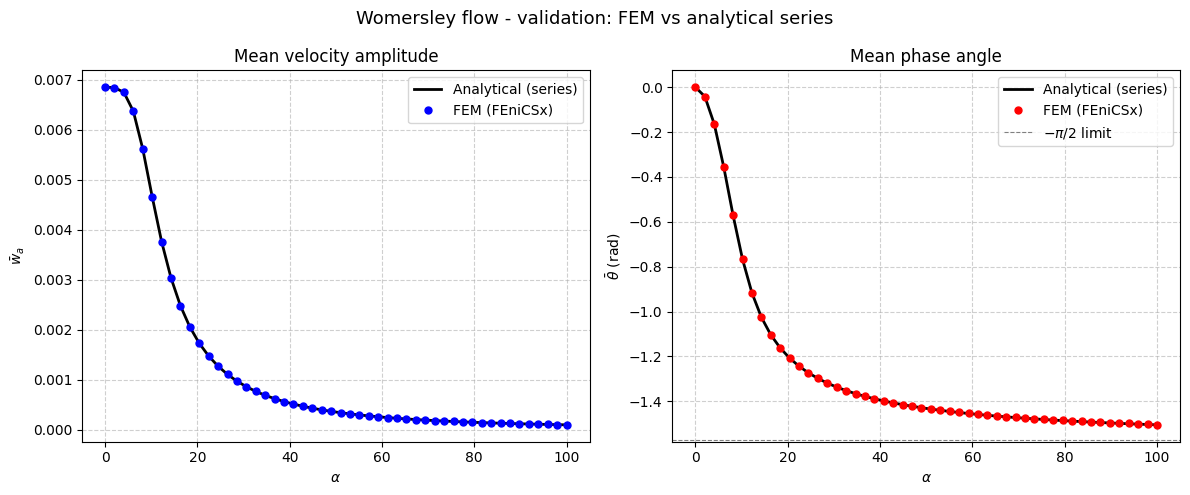

Saved: womersley_validation_fem.png


In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Womersley flow - validation: FEM vs analytical series", fontsize=13)

ax1.plot(alphas, wa_ana, "k-",  lw=2,   label="Analytical (series)")
ax1.plot(alphas, wa_fem, "bo",  ms=5,   label="FEM (FEniCSx)")
ax1.set_xlabel(r"$\alpha$");   ax1.set_ylabel(r"$\bar{w}_a$")
ax1.set_title("Mean velocity amplitude")
ax1.legend();  ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(alphas, th_ana, "k-",  lw=2,   label="Analytical (series)")
ax2.plot(alphas, th_fem, "ro",  ms=5,   label="FEM (FEniCSx)")
ax2.axhline(-np.pi/2, color="gray", ls="--", lw=0.8, label=r"$-\pi/2$ limit")
ax2.set_xlabel(r"$\alpha$");   ax2.set_ylabel(r"$\bar{\theta}$ (rad)")
ax2.set_title("Mean phase angle")
ax2.legend();  ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("womersley_validation_fem.png", dpi=150)
plt.show()
print("Saved: womersley_validation_fem.png")

## 8. Animation: Field Evolution with $\alpha$

To build physical intuition, we animate $w_a(x,y)$ and $\theta(x,y)$ as $\alpha$ increases from $0$ to $50$.

Physical interpretation of what you will see:
- **Small $\alpha$** (quasi-steady): the profile resembles **Poiseuille flow** — parabolic-like maximum at the interior, zero on the walls, zero phase lag.
- **Large $\alpha$** (inertia-dominated): the fluid cannot follow the rapid oscillation. The amplitude **collapses** everywhere and the phase lag grows toward $-\pi/2$.

The color scale is **fixed** across all frames so the amplitude decay is clearly visible. The animation is saved as a GIF using Pillow.

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

alpha_anim = np.linspace(0.0, 50.0, 50)

print("Pre-computing fields for animation (this may take a few minutes)...")
wa_frames = []
th_frames = []
for k, alpha in enumerate(alpha_anim):
    wc_a, ws_a = solve_womersley(alpha)
    wc_p = Function(V1);  wc_p.interpolate(wc_a)
    ws_p = Function(V1);  ws_p.interpolate(ws_a)
    wa_fr = np.hypot(wc_p.x.array, ws_p.x.array)
    wa_frames.append(wa_fr.copy())
    th_frames.append(np.where(wa_fr > 1e-10,
                              -np.arctan2(ws_p.x.array, wc_p.x.array),
                              0.0).copy())
    print(f"  frame {k+1:02d}/{len(alpha_anim)}  alpha={alpha:.1f}")

# Fixed color limits across all frames
wa_max = max(f.max() for f in wa_frames)
th_min = min(f.min() for f in th_frames)
th_max = max(f.max() for f in th_frames)

fig_a, axs_a = plt.subplots(1, 2, figsize=(12, 5))

tc0 = axs_a[0].tripcolor(triang, wa_frames[0], cmap="viridis",
                          shading="gouraud", vmin=0, vmax=wa_max)
plt.colorbar(tc0, ax=axs_a[0], label="$w_a$")
axs_a[0].set_aspect("equal");  axs_a[0].set_xlabel("x");  axs_a[0].set_ylabel("y")
axs_a[0].set_title("Velocity amplitude $w_a(x,y)$")

tc1 = axs_a[1].tripcolor(triang, th_frames[0], cmap="RdBu",
                          shading="gouraud", vmin=th_min, vmax=th_max)
plt.colorbar(tc1, ax=axs_a[1], label=r"$\theta$ (rad)")
axs_a[1].set_aspect("equal");  axs_a[1].set_xlabel("x");  axs_a[1].set_ylabel("y")
axs_a[1].set_title(r"Phase angle $\theta(x,y)$")

sup = fig_a.suptitle(f"Womersley flow  -  alpha = {alpha_anim[0]:.1f}", fontsize=13)
plt.tight_layout()

def update(frame):
    tc0.set_array(wa_frames[frame])
    tc1.set_array(th_frames[frame])
    sup.set_text(f"Womersley flow  -  alpha = {alpha_anim[frame]:.1f}")
    return tc0, tc1, sup

anim = FuncAnimation(fig_a, update, frames=len(alpha_anim), interval=150, blit=False)
anim.save("womersley_animation.gif", writer=PillowWriter(fps=8), dpi=100)
print("Saved: womersley_animation.gif")
# To save as MP4 instead: anim.save("womersley_animation.mp4", fps=8, dpi=100)